# Simulador de Perdas Agregadas
 O objetivo deste projeto é implementar um simulador estocástico para avaliar o perfil de perdas agregadas de uma carteira de seguros. A finalidade principal é estimar métricas de risco, como o *Value at Risk* (*VaR*) e o *Expected Shortfall* (*ES*), analisando de que forma a escolha da distribuição de severidade influencia o cálculo do capital económico necessário.

As distribuições a comparar são:
 * *Gamma*
* *Lognormal*
* *Pareto*

## 1. Lógica do Modelo
Iremos simular o montante total que uma seguradora terá de pagar num ano, *S*, repetindo este processo *10 000* vezes, de modo a construir uma distribuição empírica.

Simulamos um **único** ano da seguinte maneira:
* *Frequência (N)*: Geramos uma variável aleatória com distribuição de *Poisson* com um parâmetro $\lambda$ à nossa escolha, correspondente ao número de sinistros nesse ano;

* *Severidade (X)*: Condicionalmente a *N* sinistros, geramos *N* severidades independentes de acordo com cada uma das distribuições consideradas, representando os custos dos sinistros;

* *Perda Agregada (S)*: Corresponde à soma das *N* severidades simuladas.

Este procedimento é repetido *10 000* vezes para cada distribuição de severidade.

## 2. Escolha de Parâmetros
A escolha dos parâmetros para cada uma das distribuições dos custos tem de ser feita de modo a que todas elas tenham a **mesma** média e variância, tornando assim a comparação mais justa.

Assumem-se os seguintes valores:
* $Média = 5000$
* $Variância = 25000000$

As médias e variâncias das distribuições consideradas são dadas por:
* $Gamma(\alpha,\theta)$:  $\mathbb{E} =  \alpha \cdot \theta$ e $\text{Var} = \alpha \cdot \theta^2$
* $Lognormal(\mu,\sigma)$: $\mathbb{E} = \exp(\mu + \frac{\sigma^2}{2})$ e $\text{Var} = \exp(2 \cdot \mu + \sigma^2) \cdot (\exp(\sigma^2) -1)$
* $Pareto(x_m,\beta)$: $\mathbb{E} = \frac{\beta \cdot x_m}{\beta -1}$ e $\text{Var} = \frac{x_m^2 \cdot \beta}{(\beta - 1)^2 \cdot (\beta - 2)}$

Obtém-se, assim, os seguintes parâmetros:
* $\alpha = 1$
* $\theta = 5000$
* $\mu = 8.1706$
* $\sigma = 0.8326$
* $\beta = 2.4142$
* $x_m = 2928.93$

Quanto ao número médio de sinistros por ano, assumimos que $\lambda = 5$.

## 3. Simulação

In [5]:
import numpy as np
from IPython.display import display

# Definir a seed. Mantém os resultados iguais, independentemente de quantas vezes executamos o código
np.random.seed(15)

# Número de Anos, Taxa de Poisson (lambda) e Nº de Sinistros
n_anos = 10000
taxa = 5 # Assumimos que, em média, acontecem 5 sinistros por ano
n_sinistros = np.random.poisson(taxa,size=n_anos)

# Gamma
s_gamma = np.zeros(n_anos) # Perda Agregada assumindo a distribuição gamma para os custos
for i in range(n_anos):
    x_severidade = np.random.gamma(shape=1, scale=5000,size=n_sinistros[i])
    s_gamma[i] = x_severidade.sum()

#Lognormal
s_lognormal = np.zeros(n_anos) # Perda Agregada assumindo a distribuição lognormal para os custos
for i in range(n_anos):
    x_severidade = np.random.lognormal(mean=8.1706, sigma=0.8326, size=n_sinistros[i])
    s_lognormal[i] = x_severidade.sum()

#Pareto
s_pareto = np.zeros(n_anos) # Perda Agregada assumindo a distribuição pareto para os custos
for i in range(n_anos):
    x_severidade = (np.random.pareto(2.4142, size=n_sinistros[i]) + 1)*2928.93
    s_pareto[i] = x_severidade.sum()

print("Valores Gerados com Sucesso!")

Valores Gerados com Sucesso!


Sendo as médias e variâncias teóricas as seguintes:
* $\mathbb{E}[S] = \mathbb{E}[\sum_{i=1}^N X_i] = \mathbb{E}[N] \cdot \mathbb{E}[X] = 5 \cdot 5000 = 25000$
* $\mathbb{V}ar[S] = \mathbb{V}ar[\sum_{i=1}^N X_i] = \mathbb{E}[N] \cdot \mathbb{V}ar[X] + \mathbb{V}ar[N] \cdot \mathbb{E}[X]^2 = 5 \cdot 25000000 + 5 \cdot 5000^2 = 250000000$

Verifica-se facilmente que as respetivas métricas amostrais, além de muito próximas umas das outras, correspondem ao esperado.

In [6]:
print("Média")
print(f'Gamma: {s_gamma.mean().round(2)} \nLognormal: {s_lognormal.mean().round(2)} \nPareto: {s_pareto.mean().round(2)}')
print("")
print("Variância")
print(f'Gamma: {s_gamma.var(ddof=1).round(2)} \nLognormal: {s_lognormal.var(ddof=1).round(2)} \nPareto: {s_pareto.var(ddof=1).round(2)}')

Média
Gamma: 24880.54 
Lognormal: 24812.44 
Pareto: 24991.57

Variância
Gamma: 248920096.69 
Lognormal: 245564760.67 
Pareto: 244311528.08


No entanto, a maneira que as perdas estão distribuídas difere consoante a distribuição de severidade utilizada.
Apresentam-se, de seguida, os respetivos histogramas:

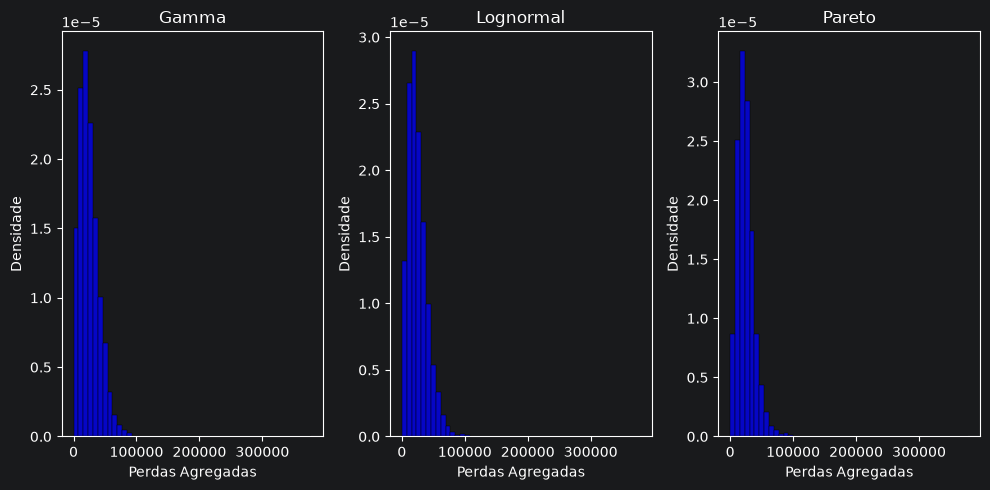

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar a grade dos gráficos
fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(10,5))

limite_max = max(s_gamma.max(),s_lognormal.max(),s_pareto.max())
bins_comuns = np.linspace(0, limite_max, 50)


#Gamma
sns.histplot(s_gamma, ax=axes[0], bins=bins_comuns, stat='density', color='blue')
axes[0].set_title("Gamma")
axes[0].set_xlabel("Perdas Agregadas")
axes[0].set_ylabel("Densidade")

#Lognormal
sns.histplot(s_lognormal, bins=bins_comuns, stat='density', color='blue', ax=axes[1])
axes[1].set_title("Lognormal")
axes[1].set_xlabel("Perdas Agregadas")
axes[1].set_ylabel("Densidade")

#Pareto
sns.histplot(s_pareto, bins=bins_comuns, stat='density', color='blue', ax=axes[2])
axes[2].set_title("Pareto")
axes[2].set_xlabel("Perdas Agregadas")
axes[2].set_ylabel("Densidade")

plt.tight_layout()
plt.show()

Estes gráficos não facilitam a visualização de valores extremos, portanto utiliza-se uma escala logarítmica no eixo y:

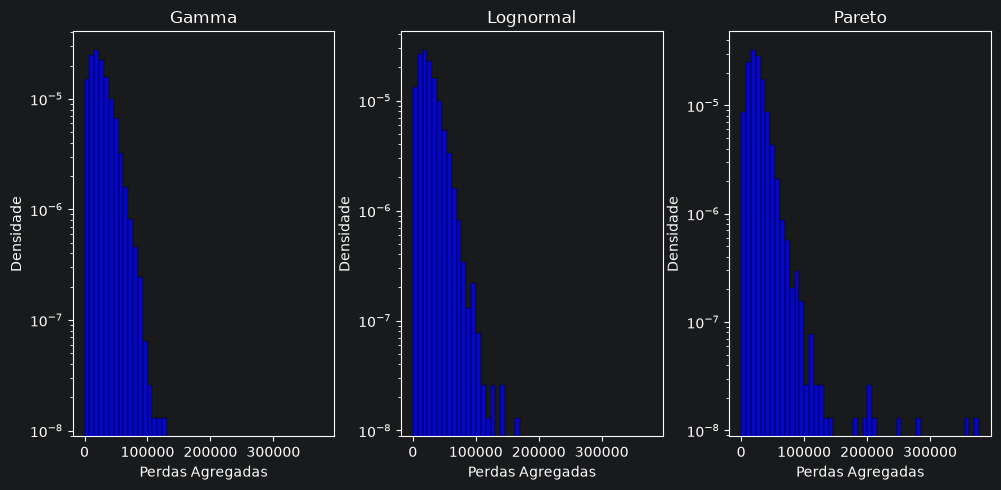

In [12]:
axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[2].set_yscale("log")

display(fig)

Os resultados simulados evidenciam caudas mais pesadas nas distribuições *Lognormal* e de *Pareto* do que na distribuição *Gamma*. Entre as distribuições consideradas, a *Pareto* apresenta os valores mais extremos, em consonância com as suas propriedades teóricas.

## 4. *VaR* 99.5%, *ES* e Capital Económico
Comparem-se agora os valores de *VaR* a 99.5%, *ES* e capital económico para os diferentes casos.

In [10]:
import pandas as pd

# Gamma
var_gamma = np.quantile(s_gamma, 0.995).round(2)
es_gamma = s_gamma[s_gamma >= var_gamma].mean().round(2)
ce_gamma = var_gamma - 25000

# Lognormal
var_lognormal = np.quantile(s_lognormal, 0.995)
es_lognormal = s_lognormal[s_lognormal >= var_lognormal].mean()
ce_lognormal = var_lognormal - 25000

# Pareto
var_pareto = np.quantile(s_pareto, 0.995)
es_pareto = s_pareto[s_pareto >= var_pareto].mean()
ce_pareto = var_pareto - 25000

# Apresentação dos Valores
tabela = pd.DataFrame(
    {
        "Distribuição": ["Gamma", "Lognormal", "Pareto"],
        "VaR 99.5%": [var_gamma, var_lognormal, var_pareto],
        "ES": [es_gamma, es_lognormal, es_pareto],
        "Capital Económico": [ce_gamma, ce_lognormal, ce_pareto],
    }
)
print(tabela.round(2))


  Distribuição  VaR 99.5%         ES  Capital Económico
0        Gamma   79881.97   89076.94           54881.97
1    Lognormal   81971.20   99082.81           56971.20
2       Pareto   86235.60  128074.40           61235.60


## 5. Conclusão
* Embora as distribuições de severidade consideradas tenham sido calibradas para apresentar a mesma média e variância, os resultados mostram que a forma da distribuição influencia as métricas associadas ao risco de cauda;
* As diferenças apresentadas no *VaR* a 99.5% são relativamente moderadas, enquanto as diferenças no *Expected Shortfall* são mais acentuadas. Em particular, a distribuição de *Pareto* apresenta um *ES* substancialmente superior, refletindo a maior probabilidade de ocorrência de perdas extremas;
* Estes resultados demonstram que métricas como a média e variância não são suficientes para caracterizar o perfil de risco de uma carteira de seguros. A escolha da distribuição é, por isso, um elemento fundamental na estimação das perdas extremas e do capital económico.